In [1]:
include("BarrierSynthesis.jl")
# include("PlotBarriers.jl")

compute_next_level_barriersPM (generic function with 1 method)

In [2]:
@polyvar u[1:2]
@polyvar(x[1:6]) # x[1] is x, x[2] is y, x[3] is vel, x[4] is θ, x[5] is ω, x[6] is error
    dynamics = [
        (ctrl -> [x[3]*(2.0/π)*(x[4] + π/2.0)-0.2x[6],x[3]*(-2.0/π)*(x[4]+π)-0.2x[6], ctrl[1], x[5], ctrl[2], 0.]),
        (ctrl -> [x[3]*(2.0/π)*(x[4] + π/2.0)-0.2x[6],x[3]*(2.0/π)*x[4]+0.2x[6], ctrl[1], x[5], ctrl[2], 0]),
        (ctrl -> [x[3]*(-2.0/π)*(x[4] - π/2.0)+0.2x[6],x[3]*(2.0/π)*x[4]+0.2x[6], ctrl[1], x[5], ctrl[2], 0]),
        (ctrl -> [x[3]*(-2.0/π)*(x[4] - π/2.0)+0.2x[6],x[3]*(-2.0/π)*(x[4]-π)-0.2x[6], ctrl[1], x[5], ctrl[2], 0]),
    ]
g = 0.1^2 - x[1]^2 - x[2]^2 # Obstacle: is a (x,y) ball of radius 0.1 around origin
bounds = [[-20., 20.], [-20., 20.], [-20.,20.],[-π,π], [-20.,20.],[-1.,1.]]

6-element Vector{Vector{Float64}}:
 [-20.0, 20.0]
 [-20.0, 20.0]
 [-20.0, 20.0]
 [-3.141592653589793, 3.141592653589793]
 [-20.0, 20.0]
 [-1.0, 1.0]

In [ ]:
# λ = 1
K =1.5
δ = 0.5
ϵ = 0.02
α = 0.1
max_degree=2
U = [[-3., -3.], [-3., 3.], [3., -3.], [3., 3.]]
# U = [[-5., -5.], [-5., 5.], [5., -5.], [5., 5.]]
n_tests = 200

200

In [4]:
test_pts = [ get_random(bounds, g) for _ in 1:n_tests]

200-element Vector{Vector{Float64}}:
 [17.209703069534456, 7.065618793010199, -0.6783425868169317, -1.5080073875854512, -13.0463444232768, 0.2801078020851957]
 [-1.1122373222173465, -16.43910085791116, -0.8994690556385301, -1.3632706699504895, 7.650575421793381, -0.4975735922513471]
 [12.373906969012147, 8.803779008427576, 1.0310232875830891, -0.5038347801637544, -15.898324816895396, 0.7942023438445038]
 [10.090986746872723, 4.725070481805961, 17.312553440959064, 1.1315348948190804, 3.8648312239796425, -0.46748354805007253]
 [-18.244675526054472, -11.731328647023522, 1.3245300754180747, 2.785245472093159, -14.625219458647404, 0.313039878792438]
 [-15.064602157561175, 9.474768709506634, -6.804307077807943, 0.004187381466151052, -18.35570336870213, -0.6243839277071743]
 [4.667722499413003, 2.058996075179593, 7.449747435728277, -1.3847479295679774, -10.67482956301931, 0.4230020689310503]
 [9.954686924439542, -4.186010685025865, -0.6152516643093655, -0.21062987019097656, 10.70056874658318,

In [5]:
function findRepulsiveBarrier_HybridCT(x, ctrl::Vector{Float64}, g, dynamics, test_pts; max_degree=4, ϵ=1.0, τ=0.1, γ=10.0, K=1.0, δ=1.0, α=1.0, state_bounds=bounds)
    function prepare_domain_hybrid(var, lb, ub)
        dom = @set(var >= lb) ∩ @set(var <= ub) ∩ @set((var - lb) * (ub - var) >= 0)
        return dom
    end

    @assert τ > 0.0 "τ must be positive."
    @assert δ > 0.0 "δ must be positive."
    @assert K >= 0.0 "K must be nonnegative."
    @assert α > 0.0 "α must be positive."

    λ = (1.0 / τ) * log(1.0 + K / δ)

    solver = optimizer_with_attributes(MosekTools.Optimizer)
    model = SOSModel(solver)
    monos = monomials(x, 0:max_degree)
    N = length(monos)
    @variable(model, -γ <= c[1:N] <= γ)
    B = polynomial(c[1:end], monos)

    dom_list = prepare_domain(x, state_bounds)
    D = reduce((s1, s2) -> s1 ∩ s2, dom_list)
    println("Domain: $D")

    # 1) Unsafe-set positivity on obstacle states (g >= 0 denotes the obstacle interior)
    @constraint(model, B >= ϵ, domain = D ∩ @set(g >= 0))

    # 2) Decrease condition under each hybrid mode and fixed control
    for (i, dyn_i) in enumerate(dynamics)
        dyn_with_ctrl = dyn_i(ctrl)
        dBdt = dot(differentiate(B, x), dyn_with_ctrl)
        dom_i = prepare_domain_hybrid(x[4], (i - 3) * π / 2, (i - 2) * π / 2)
        @constraint(model, dBdt <= λ * B, domain = D ∩ dom_i)
    end

    # 3) Bounded-jump condition: B(y - yo, z) - B(y, z) <= K for yo in obstacle set
    @polyvar q1 q2
    Qα = @set(α^2 - q1^2 - q2^2 >= 0)
    B_shift = subs(B, x[1] => x[1] - q1, x[2] => x[2] - q2)
    @constraint(model, K >= B_shift - B, domain = D ∩ Qα)

    # set_objective_sense(model, MOI.FEASIBILITY_SENSE)
   set_objective_sense(model, MOI.MIN_SENSE) 
    objective_fn = sum((B(pt...) for pt in test_pts); init=0.0)
    # With unsafe encoded as B > 0, minimize B on test points to expand certified safe set B <= 0.
    @objective(model, Min, objective_fn)

    JuMP.optimize!(model)
    stat = JuMP.primal_status(model)
    solution_summary(model)
    println("Status obtained: $(stat)")
    if stat != FEASIBLE_POINT
        return missing
    end

    return value(B), K
end

findRepulsiveBarrier_HybridCT (generic function with 1 method)

In [ ]:
res_1 = findRepulsiveBarrier_HybridCT(x, U[1], g, dynamics, test_pts; max_degree=max_degree, ϵ, K, δ, α)
@assert res_1 !== missing "Failed to synthesize barrier for U[1]"
B_1, K_1 = res_1
display(B_1)
display(K_1)
# Keep points not yet certified safe (B > 0) for subsequent barrier synthesis.
test_pts = filter!(pt -> B_1(pt...) > 0.0, test_pts)

Domain: { (x[1], x[2], x[3], x[4], x[5], x[6]) | 20.0 + x[1] ≥ 0, 20.0 - x[1] ≥ 0, 400.0 - x[1]^2 ≥ 0, 20.0 + x[2] ≥ 0, 20.0 - x[2] ≥ 0, 400.0 - x[2]^2 ≥ 0, 20.0 + x[3] ≥ 0, 20.0 - x[3] ≥ 0, 400.0 - x[3]^2 ≥ 0, 3.141592653589793 + x[4] ≥ 0, 3.141592653589793 - x[4] ≥ 0, 9.869604401089358 - x[4]^2 ≥ 0, 20.0 + x[5] ≥ 0, 20.0 - x[5] ≥ 0, 400.0 - x[5]^2 ≥ 0, 1.0 + x[6] ≥ 0, 1.0 - x[6] ≥ 0, 1.0 - x[6]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 409             
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 94              
  Matrix variables       : 62 (scalarized: 1753)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator

0.019998674804711868 + 1.0901801170626268e-7x₆ - 2.254064234653742e-8x₅ - 1.6396982952806884e-7x₄ - 1.478880924451278e-6x₃ + 2.3963298650478922e-8x₂ + 8.231143911418038e-10x₁ + 8.764044287294421e-7x₆² - 1.707815727544818e-9x₅x₆ + 1.1468779695754673e-8x₅² - 7.999113466834003e-8x₄x₆ + 6.996926655841445e-9x₄x₅ + 9.474787147429706e-8x₄² - 1.882920845825128e-7x₃x₆ + 7.807817651581745e-8x₃x₅ + 8.763101715773503e-7x₃x₄ + 3.2521889070143746e-6x₃² + 7.147363999888542e-8x₂x₆ - 3.929312204293431e-9x₂x₅ - 1.4543106742112113e-8x₂x₄ - 9.797468661659292e-9x₂x₃ - 2.441673795085372e-8x₂² + 2.3472504851896288e-8x₁x₆ - 6.063109437019757e-8x₁x₅ - 7.968904852043129e-7x₁x₄ + 8.544691279723706e-10x₁x₃ + 2.1322650496884513e-9x₁x₂ - 4.650080080196424e-5x₁²

1.5

200-element Vector{Vector{Float64}}:
 [17.209703069534456, 7.065618793010199, -0.6783425868169317, -1.5080073875854512, -13.0463444232768, 0.2801078020851957]
 [-1.1122373222173465, -16.43910085791116, -0.8994690556385301, -1.3632706699504895, 7.650575421793381, -0.4975735922513471]
 [12.373906969012147, 8.803779008427576, 1.0310232875830891, -0.5038347801637544, -15.898324816895396, 0.7942023438445038]
 [10.090986746872723, 4.725070481805961, 17.312553440959064, 1.1315348948190804, 3.8648312239796425, -0.46748354805007253]
 [-18.244675526054472, -11.731328647023522, 1.3245300754180747, 2.785245472093159, -14.625219458647404, 0.313039878792438]
 [-15.064602157561175, 9.474768709506634, -6.804307077807943, 0.004187381466151052, -18.35570336870213, -0.6243839277071743]
 [4.667722499413003, 2.058996075179593, 7.449747435728277, -1.3847479295679774, -10.67482956301931, 0.4230020689310503]
 [9.954686924439542, -4.186010685025865, -0.6152516643093655, -0.21062987019097656, 10.70056874658318,

In [ ]:
res_2 = findRepulsiveBarrier_HybridCT(x, U[2], g, dynamics, test_pts; max_degree=max_degree, ϵ, K, δ, α)
@assert res_2 !== missing "Failed to synthesize barrier for U[2]"
B_2, K_2 = res_2
display(B_2)
display(K_2)
test_pts = filter!(pt -> B_2(pt...) > 0.0, test_pts)

Domain: { (x[1], x[2], x[3], x[4], x[5], x[6]) | 20.0 + x[1] ≥ 0, 20.0 - x[1] ≥ 0, 400.0 - x[1]^2 ≥ 0, 20.0 + x[2] ≥ 0, 20.0 - x[2] ≥ 0, 400.0 - x[2]^2 ≥ 0, 20.0 + x[3] ≥ 0, 20.0 - x[3] ≥ 0, 400.0 - x[3]^2 ≥ 0, 3.141592653589793 + x[4] ≥ 0, 3.141592653589793 - x[4] ≥ 0, 9.869604401089358 - x[4]^2 ≥ 0, 20.0 + x[5] ≥ 0, 20.0 - x[5] ≥ 0, 400.0 - x[5]^2 ≥ 0, 1.0 + x[6] ≥ 0, 1.0 - x[6] ≥ 0, 1.0 - x[6]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 409             
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 94              
  Matrix variables       : 62 (scalarized: 1753)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator

0.019952834190700878 + 1.1403677752798253e-7x₆ - 1.7787320668527898e-9x₅ - 1.1110804008194218e-7x₄ - 1.121036329227414e-6x₃ + 3.3578210904618e-8x₂ - 7.264926125762705e-8x₁ + 8.265476018736746e-7x₆² + 1.1310089959808231e-8x₅x₆ + 1.2266429108323863e-7x₅² - 1.4363862091007436e-7x₄x₆ - 1.1322661331479612e-8x₄x₅ + 1.5751006111925938e-7x₄² - 1.9680899393257348e-7x₃x₆ - 2.480024746467069e-8x₃x₅ + 1.174200640777766e-6x₃x₄ + 3.2746159042072123e-6x₃² + 5.6016601168025866e-8x₂x₆ + 6.074861093072048e-9x₂x₅ - 9.06431809005487e-9x₂x₄ - 3.436958535187077e-8x₂x₃ + 4.1019541106883496e-8x₂² + 9.926397194762503e-8x₁x₆ - 4.718166178070566e-9x₁x₅ - 7.034011226310492e-7x₁x₄ + 1.2914499891137497e-8x₁x₃ - 2.57292332404519e-8x₁x₂ - 4.6366411581665325e-5x₁²

1.5

200-element Vector{Vector{Float64}}:
 [17.209703069534456, 7.065618793010199, -0.6783425868169317, -1.5080073875854512, -13.0463444232768, 0.2801078020851957]
 [-1.1122373222173465, -16.43910085791116, -0.8994690556385301, -1.3632706699504895, 7.650575421793381, -0.4975735922513471]
 [12.373906969012147, 8.803779008427576, 1.0310232875830891, -0.5038347801637544, -15.898324816895396, 0.7942023438445038]
 [10.090986746872723, 4.725070481805961, 17.312553440959064, 1.1315348948190804, 3.8648312239796425, -0.46748354805007253]
 [-18.244675526054472, -11.731328647023522, 1.3245300754180747, 2.785245472093159, -14.625219458647404, 0.313039878792438]
 [-15.064602157561175, 9.474768709506634, -6.804307077807943, 0.004187381466151052, -18.35570336870213, -0.6243839277071743]
 [4.667722499413003, 2.058996075179593, 7.449747435728277, -1.3847479295679774, -10.67482956301931, 0.4230020689310503]
 [9.954686924439542, -4.186010685025865, -0.6152516643093655, -0.21062987019097656, 10.70056874658318,

In [ ]:
res_3 = findRepulsiveBarrier_HybridCT(x, U[3], g, dynamics, test_pts; max_degree=max_degree, ϵ, K, δ, α)
@assert res_3 !== missing "Failed to synthesize barrier for U[3]"
B_3, K_3 = res_3
display(B_3)
display(K_3)
test_pts = filter!(pt -> B_3(pt...) > 0.0, test_pts)

Domain: { (x[1], x[2], x[3], x[4], x[5], x[6]) | 20.0 + x[1] ≥ 0, 20.0 - x[1] ≥ 0, 400.0 - x[1]^2 ≥ 0, 20.0 + x[2] ≥ 0, 20.0 - x[2] ≥ 0, 400.0 - x[2]^2 ≥ 0, 20.0 + x[3] ≥ 0, 20.0 - x[3] ≥ 0, 400.0 - x[3]^2 ≥ 0, 3.141592653589793 + x[4] ≥ 0, 3.141592653589793 - x[4] ≥ 0, 9.869604401089358 - x[4]^2 ≥ 0, 20.0 + x[5] ≥ 0, 20.0 - x[5] ≥ 0, 400.0 - x[5]^2 ≥ 0, 1.0 + x[6] ≥ 0, 1.0 - x[6] ≥ 0, 1.0 - x[6]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 409             
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 94              
  Matrix variables       : 62 (scalarized: 1753)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator

0.019998916293909454 + 2.1634072348210867e-8x₆ - 2.844337130607376e-9x₅ + 5.132739165741811e-7x₄ + 2.745031343858455e-6x₃ + 2.3515198060453274e-8x₂ + 6.388606602405099e-9x₁ + 5.2897838923518735e-8x₆² - 1.6963328033523692e-9x₅x₆ + 8.845717096543038e-9x₅² - 6.412402496976275e-8x₄x₆ + 1.518523639034787e-9x₄x₅ + 1.4099426893913504e-7x₄² + 6.795525041892903e-8x₃x₆ - 1.2496805167170113e-8x₃x₅ + 1.2289818565796431e-6x₃x₄ + 3.3189398367066285e-6x₃² + 4.2243535933129206e-8x₂x₆ - 1.9418066972305883e-9x₂x₅ - 1.3904902283199559e-9x₂x₄ + 1.0690946148011911e-8x₂x₃ - 2.0975431912783998e-8x₂² + 1.1219972781221304e-6x₁x₆ - 3.4327243743234256e-8x₁x₅ - 8.05881915659277e-7x₁x₄ + 6.000032153206923e-8x₁x₃ + 1.3328620670978939e-8x₁x₂ - 4.653917436460651e-5x₁²

1.5

200-element Vector{Vector{Float64}}:
 [17.209703069534456, 7.065618793010199, -0.6783425868169317, -1.5080073875854512, -13.0463444232768, 0.2801078020851957]
 [-1.1122373222173465, -16.43910085791116, -0.8994690556385301, -1.3632706699504895, 7.650575421793381, -0.4975735922513471]
 [12.373906969012147, 8.803779008427576, 1.0310232875830891, -0.5038347801637544, -15.898324816895396, 0.7942023438445038]
 [10.090986746872723, 4.725070481805961, 17.312553440959064, 1.1315348948190804, 3.8648312239796425, -0.46748354805007253]
 [-18.244675526054472, -11.731328647023522, 1.3245300754180747, 2.785245472093159, -14.625219458647404, 0.313039878792438]
 [-15.064602157561175, 9.474768709506634, -6.804307077807943, 0.004187381466151052, -18.35570336870213, -0.6243839277071743]
 [4.667722499413003, 2.058996075179593, 7.449747435728277, -1.3847479295679774, -10.67482956301931, 0.4230020689310503]
 [9.954686924439542, -4.186010685025865, -0.6152516643093655, -0.21062987019097656, 10.70056874658318,

In [ ]:
res_4 = findRepulsiveBarrier_HybridCT(x, U[4], g, dynamics, test_pts; max_degree=max_degree, ϵ, K, δ, α)
@assert res_4 !== missing "Failed to synthesize barrier for U[4]"
B_4, K_4 = res_4
display(B_4)
display(K_4)
test_pts = filter!(pt -> B_4(pt...) > 0.0, test_pts)

Domain: { (x[1], x[2], x[3], x[4], x[5], x[6]) | 20.0 + x[1] ≥ 0, 20.0 - x[1] ≥ 0, 400.0 - x[1]^2 ≥ 0, 20.0 + x[2] ≥ 0, 20.0 - x[2] ≥ 0, 400.0 - x[2]^2 ≥ 0, 20.0 + x[3] ≥ 0, 20.0 - x[3] ≥ 0, 400.0 - x[3]^2 ≥ 0, 3.141592653589793 + x[4] ≥ 0, 3.141592653589793 - x[4] ≥ 0, 9.869604401089358 - x[4]^2 ≥ 0, 20.0 + x[5] ≥ 0, 20.0 - x[5] ≥ 0, 400.0 - x[5]^2 ≥ 0, 1.0 + x[6] ≥ 0, 1.0 - x[6] ≥ 0, 1.0 - x[6]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 409             
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 94              
  Matrix variables       : 62 (scalarized: 1753)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator

0.019945231506414064 + 1.6326361562322988e-8x₆ + 1.815740942587862e-8x₅ - 2.7576993243592274e-10x₄ - 4.457075486601138e-8x₃ + 1.3831809618916575e-8x₂ - 4.6857104426057666e-8x₁ + 9.443310162138004e-8x₆² + 7.2802653597810425e-9x₅x₆ + 1.20152202894639e-7x₅² - 1.1739842077840086e-7x₄x₆ + 4.528289346440497e-9x₄x₅ + 5.968333096281866e-8x₄² - 9.171161387204631e-7x₃x₆ + 1.701886787776115e-8x₃x₅ + 8.191937999292966e-7x₃x₄ + 3.3980481428528015e-6x₃² + 8.326881438433505e-8x₂x₆ + 1.4294539167964078e-9x₂x₅ - 9.63307698743348e-9x₂x₄ - 2.5004328040503827e-8x₂x₃ + 9.637474172330603e-8x₂² + 1.6988838900327657e-8x₁x₆ - 4.6182268912249595e-9x₁x₅ - 2.290879144614522e-7x₁x₄ + 3.117201007902644e-8x₁x₃ - 1.21217189533935e-8x₁x₂ - 4.639344322324479e-5x₁²

1.5

200-element Vector{Vector{Float64}}:
 [17.209703069534456, 7.065618793010199, -0.6783425868169317, -1.5080073875854512, -13.0463444232768, 0.2801078020851957]
 [-1.1122373222173465, -16.43910085791116, -0.8994690556385301, -1.3632706699504895, 7.650575421793381, -0.4975735922513471]
 [12.373906969012147, 8.803779008427576, 1.0310232875830891, -0.5038347801637544, -15.898324816895396, 0.7942023438445038]
 [10.090986746872723, 4.725070481805961, 17.312553440959064, 1.1315348948190804, 3.8648312239796425, -0.46748354805007253]
 [-18.244675526054472, -11.731328647023522, 1.3245300754180747, 2.785245472093159, -14.625219458647404, 0.313039878792438]
 [-15.064602157561175, 9.474768709506634, -6.804307077807943, 0.004187381466151052, -18.35570336870213, -0.6243839277071743]
 [4.667722499413003, 2.058996075179593, 7.449747435728277, -1.3847479295679774, -10.67482956301931, 0.4230020689310503]
 [9.954686924439542, -4.186010685025865, -0.6152516643093655, -0.21062987019097656, 10.70056874658318,

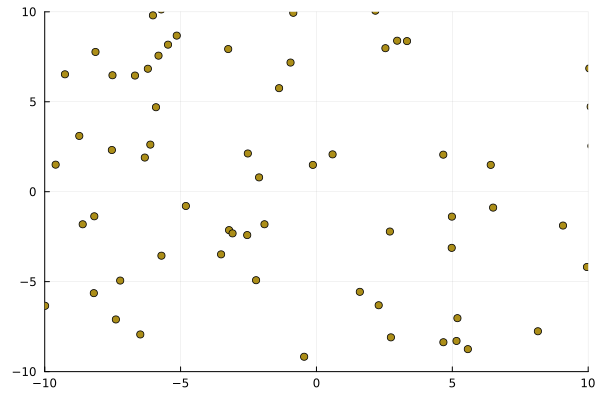

In [10]:
using Plots

function make_contour_plot(B::Polynomial, limits ::Tuple{Float64,Float64}, clr::String; x3_val=0.0, x4_val=0.0, x5_val=0.0, x6_val=0.0)
    x = range(limits[1], limits[2], length=500)
    y = range(limits[1], limits[2], length=500)
    my_fun(xa::Float64,ya::Float64) = B([xa, ya, x3_val, x4_val,x5_val, x6_val])
    z = @.my_fun(x', y)
    # Draw the certified boundary (0-level) and nearby level sets for visibility.
    contour!(x, y, z, levels=[0.0, 0.01, 0.02], color=clr, colorbar=false)
end

limits=(-10., 10.)
plot(xlims = limits, ylims = limits)
# make_contour_plot(g, limits,"red") 
make_contour_plot(B_1, limits, "black")
make_contour_plot(B_2, limits, "blue")
make_contour_plot(B_3, limits,"green")
make_contour_plot(B_4, limits, "orange")
plot!([x1 for (x1,_) in test_pts], [x2 for (_, x2) in test_pts], seriestype=:scatter, labels=false)


In [11]:
using LaTeXStrings
function circleShape(x,y, r)
    θ = LinRange(0, 2*π, 500)
    x .+ r*cos.(θ), y .+ r*sin.(θ)
end
function plot_ics_region(limits::Tuple{Float64,Float64}, all_barriers::Vector{<:Polynomial}; δ = 0.5, x3_val=10, x4_val=π/2,x5_val=1.,x6_val=0.)
    plot(xlims=limits, ylims=limits)
    rectangle(w, h, x, y) = Shape(x .+ [0,w,w,0], y .+ [0,0,h,h])
    pts = vec(collect(Iterators.product(limits[1]:δ:limits[2], limits[1]:δ:limits[2])))
    minB = [minimum(B(px, py, x3_val, x4_val, x5_val, x6_val) for B in all_barriers) for (px, py) in pts]
    has_strict_safe = any(v -> v <= 0.0, minB)
    thresh = 0.0
    fill_color = :green
    fill_label = "B <= 0"
    if !has_strict_safe
        # Fallback for difficult slices: show a near-safe band so the plot is informative.
        sorted_vals = sort(copy(minB))
        idx = max(1, Int(floor(0.08 * length(sorted_vals))))
        thresh = sorted_vals[idx]
        fill_color = :orange
        fill_label = "near-safe"
    end
    for ((px, py), v) in zip(pts, minB)
        if v <= thresh
            plot!(rectangle(δ, δ, px-δ, py-δ), label=false, fill=fill_color, opacity=0.45, linecolor=fill_color)
        end
    end
    plot!(circleShape(0,0,1.), seriestype =[:shape], lw=0.5, c=:black, linecolor=:black, legend=false, aspectratio=1  )
    plot!(xlims=limits, ylims=limits, title="Safe slice (x3=$(round(x3_val, digits=2)), x4=$(round(x4_val, digits=2)), x5=$(round(x5_val, digits=2)); $fill_label)")
end

plot_ics_region (generic function with 1 method)

In [12]:
all_barriers = [B_1, B_2, B_3, B_4]

4-element Vector{Polynomial{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, Graded{LexOrder}, Float64}}:
 0.019998674804711868 + 1.0901801170626268e-7x₆ - 2.254064234653742e-8x₅ - 1.6396982952806884e-7x₄ - 1.478880924451278e-6x₃ + 2.3963298650478922e-8x₂ + 8.231143911418038e-10x₁ + 8.764044287294421e-7x₆² - 1.707815727544818e-9x₅x₆ + 1.1468779695754673e-8x₅² - 7.999113466834003e-8x₄x₆ + 6.996926655841445e-9x₄x₅ + 9.474787147429706e-8x₄² - 1.882920845825128e-7x₃x₆ + 7.807817651581745e-8x₃x₅ + 8.763101715773503e-7x₃x₄ + 3.2521889070143746e-6x₃² + 7.147363999888542e-8x₂x₆ - 3.929312204293431e-9x₂x₅ - 1.4543106742112113e-8x₂x₄ - 9.797468661659292e-9x₂x₃ - 2.441673795085372e-8x₂² + 2.3472504851896288e-8x₁x₆ - 6.063109437019757e-8x₁x₅ - 7.968904852043129e-7x₁x₄ + 8.544691279723706e-10x₁x₃ + 2.1322650496884513e-9x₁x₂ - 4.650080080196424e-5x₁²
 0.019952834190700878 + 1.1403677752798253e-7x₆ - 1.7787320668527898e-9x₅ - 1.1110804008194218e-7x₄ - 1.121036329227414e-6x₃ + 3.35782

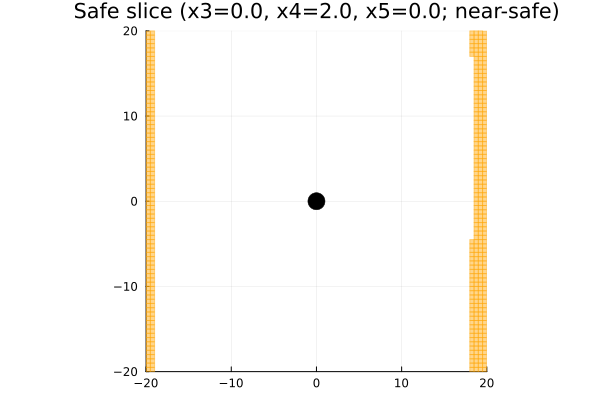

In [13]:
plot_ics_region((-20.0, 20.0), all_barriers; x3_val=0.0, x4_val=2.0, x5_val=0.0, x6_val=0.0)

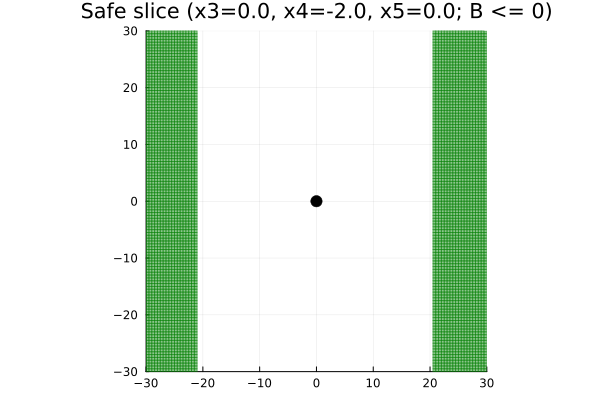

In [14]:
plot_ics_region((-30.0, 30.0), all_barriers; x3_val=0.0, x4_val=-2.0, x5_val=0.0, x6_val=0.0)

Simulation finished
minimum recentered barrier value = 0.005756547714337932

┌ Info: Saved animation to /Users/rameez/workspace/moving_obs_barrier/figures/repulsive_hybrid_coordturn_moving_obstacle.gif
└ @ Plots /Users/rameez/.julia/packages/Plots/xKhUG/src/animation.jl:156


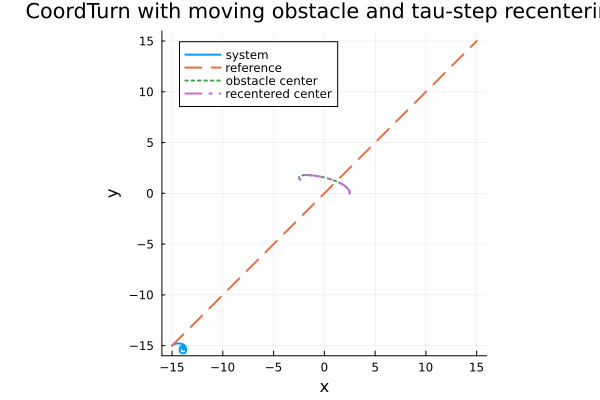

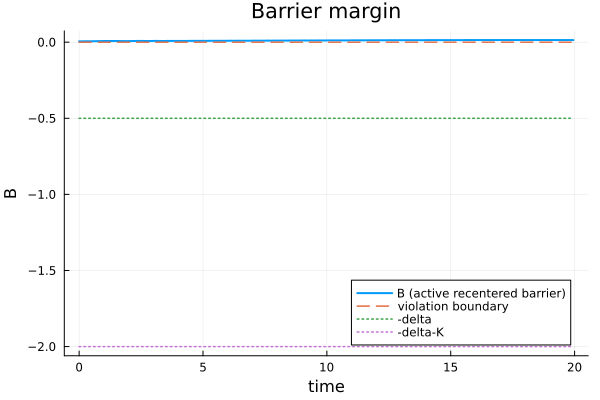

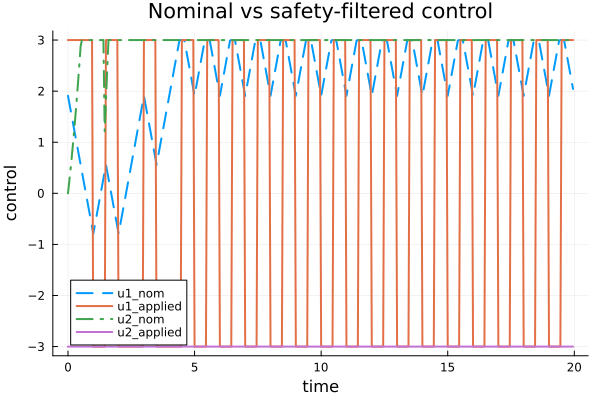


minimum true obstacle distance = 20.087411935484926
mean tracking error = 20.621657137734296
max tracking error = 41.66746872661751
number of barrier overrides = 400
Animation saved to figures/repulsive_hybrid_coordturn_moving_obstacle.gif
GIF saved to: figures/repulsive_hybrid_coordturn_moving_obstacle.gif


In [15]:
include("Repulsive_hybrid_CoordTurn_recenter_fix.jl")
barrier_controls = [(U[1][1], U[1][2]), (U[2][1], U[2][2]), (U[3][1], U[3][2]), (U[4][1], U[4][2])]
delta_sim = δ
K_sim = K
res = run_repulsive_hybrid_coordturn_demo(
    all_barriers;
    barrier_controls=barrier_controls,
    delta=delta_sim,
    k_override=K_sim,
    dt=0.05,
    T=20.0,
    tau_steps=10,
    x0=[-15.0, -15.0, 0.0, π/4, 0.0, 0.0],
    ref_start=[-15.0, -15.0],
    ref_end=[15.0, 15.0],
    ref_T=20.0,
)
display(res.p_traj); display(res.p_B); display(res.p_u)
println("GIF saved to: ", res.gif_path)